In [1]:
import os
from pathlib import Path
import torch
import numpy as np
import matplotlib.pylab as plt
from omegaconf import OmegaConf
import librosa

from diffusion_hub.diffusion import SDEDiffusion
from diffusion_hub.diffusion.spect_model import GradLogPEstimator2d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
config_file = '/home/ahmedb/projects/diffusion-hub/configs/train_configs/spect_diffusion.yaml'
model_config = OmegaConf.load(config_file).model

estimator = GradLogPEstimator2d(**model_config.net_config)
diff_model = SDEDiffusion(estimator, **model_config.diffusion_config)

checkpoint = torch.load(model_config.checkpoint, map_location="cpu")['model_state_dict']
diff_model.load_state_dict(checkpoint)

diff_model.eval()
diff_model = diff_model.to(device)

/tmp/ipykernel_1727571/839950913.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_config.checkpoint, map_location="cpu")['model_state_dict']

In [3]:
z = torch.randn(4, 80, 256).cuda()
samples = diff_model.reverse_diffusion(z, n_timesteps=100)

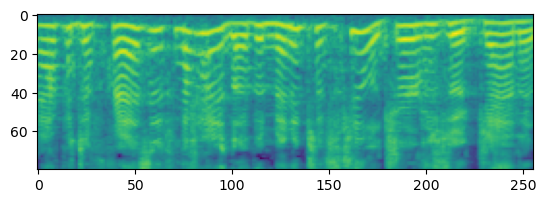

In [4]:
idx=1
plt.imshow(samples[idx].squeeze().cpu().numpy())

In [5]:
from IPython.display import Audio

idx=1
audio = librosa.feature.inverse.mel_to_audio(
        samples[idx].squeeze().cpu().numpy(),
        sr=22050,
        n_fft=1024,
        hop_length=256,
        win_length=1024,
        window='hamming',
        )

Audio(audio, rate=22050)

### hifi-GAN

In [6]:
import json
import os
import shutil


class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

config_file = '/depot/jgmakin/data/bilal/pretrained_models/hifi-gan/LJ_V1/config.json'
with open(config_file) as f:
    data = f.read()

json_config = json.loads(data)
h = AttrDict(json_config)

In [ ]:
from models import Generator

generator = Generator(h)

hifi_checkpoint = '/depot/jgmakin/data/bilal/pretrained_models/hifi-gan/LJ_V1/generator_v1'
state_dict_g = torch.load(hifi_checkpoint, map_location='cpu')
generator.load_state_dict(state_dict_g['generator'])

generator.eval()
generator = generator.to(device)


/tmp/ipykernel_1727571/181129949.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict_g = torch.load(hifi_checkpoint, map_location='cpu')


In [21]:
wavs = generator(samples).detach()

In [26]:
idx=3
Audio(wavs[idx].squeeze().cpu().numpy(), rate=22050)